# 1. Base de datos

## 1.1 Reserva del conjunto de prueba

Antes de mirar cualquier estadístico se separa el conjunto de prueba: **la finca (sitio no visto) en 2021–2025**. El entrenamiento usa los sitios regionales hasta 2020. Los datos de 2021–2025 de los sitios regionales no se usan, porque comparten los mismos eventos climáticos que la finca y producirían fuga. Todas las decisiones de imputación, transformación, selección de variables y umbrales se toman solo con el entrenamiento.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
np.random.seed(cfg.SEED)
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv(cfg.DATA_PROCESSED / cfg.ARCHIVO_DATOS, parse_dates=["fecha"])
OBJ = "PRECTOTCORR"
futuro = df["fecha"] >= cfg.INICIO_TEST
if df["punto"].nunique() == 1:      # plan B: un solo sitio, partición cronológica
    train_df, test_df = df[~futuro].copy(), df[futuro].copy()
else:                               # diseño regional: sitio no visto y años futuros
    es_finca = df["punto"] == cfg.PUNTO_OBJETIVO
    train_df, test_df = df[~es_finca & ~futuro].copy(), df[es_finca & futuro].copy()
print(f"Entrenamiento: {train_df.punto.nunique()} sitio(s), {train_df.fecha.min().date()} → {train_df.fecha.max().date()} ({len(train_df):,} filas)")
print(f"Prueba:        {test_df.fecha.min().date()} → {test_df.fecha.max().date()} ({len(test_df):,} filas)")
print(f"Sin uso:       {len(df) - len(train_df) - len(test_df):,} filas")

Entrenamiento: 1 sitio(s), 1981-01-01 → 2020-12-31 (14,610 filas)
Prueba:        2021-01-01 → 2025-12-31 (1,826 filas)
Sin uso:       0 filas


## 1.2 Tamaño de la muestra

In [3]:
VARS = [c for c in cfg.POWER_PARAMS if c in df] + ["ET0"] + (["ONI"] if "ONI" in df else [])
n, p = len(df), len(VARS)
print(f"Observaciones (punto-día): {n:,}  (mínimo exigido: 20.000)")
print(f"Variables: {p}   relación n/p: {n/p:,.0f}")
print(f"Sitios: {df.punto.nunique()}")
if len(df) < 20000:
    print("ADVERTENCIA: menos de 20.000 observaciones (mínimo sugerido por la guía). Se declara como limitación.")
print(f"Días distintos: {df.fecha.nunique():,}")
print(f"Rango del objetivo diario: {df[OBJ].min():.1f} – {df[OBJ].max():.1f} mm/día")
from src import modelado as md
semanal = md.semanal_por_punto(df, [OBJ])[OBJ]
if df.punto.nunique() > 1:
    print("Advertencia: los sitios vecinos comparten eventos climáticos; en 45 años hay del orden de 15 episodios de El Niño o La Niña.")
print(f"Rango del objetivo semanal: {semanal.min():.1f} – {semanal.max():.1f} mm/semana")

Observaciones (punto-día): 16,436  (mínimo exigido: 20.000)
Variables: 11   relación n/p: 1,494
Sitios: 1
ADVERTENCIA: menos de 20.000 observaciones (mínimo sugerido por la guía). Se declara como limitación.
Días distintos: 16,436
Rango del objetivo diario: 0.0 – 229.6 mm/día
Rango del objetivo semanal: 0.0 – 370.3 mm/semana


**Tamaño efectivo.** Los días consecutivos están autocorrelacionados y los puntos vecinos comparten clima, así que el número de observaciones independientes es bastante menor que el número de filas. Por eso la validación es cronológica y los intervalos de confianza se calculan con bootstrap por bloques.

## 1.3 Diccionario de variables

In [4]:
diccionario = pd.DataFrame([
    ("fecha", "fecha", "-", "Día de la observación (hora estándar local, escala diaria)"),
    ("punto", "categórica", "-", "Identificador del sitio (REGIONAL_### o FINCA_SABANAGRANDE)"),
    ("tipo_punto", "categórica", "-", "regional (entrenamiento) o finca_prueba"),
    ("lat, lon", "numérica", "grados (EPSG:4326)", "Coordenadas devueltas por POWER"),
    ("elevacion_m", "numérica", "m", "Elevación del punto según POWER"),
    ("PRECTOTCORR", "numérica", "mm/día", "Precipitación total corregida (OBJETIVO)"),
    ("T2M, T2M_MAX, T2M_MIN", "numérica", "°C", "Temperatura media, máxima y mínima a 2 m"),
    ("RH2M", "numérica", "%", "Humedad relativa a 2 m"),
    ("WS2M", "numérica", "m/s", "Velocidad del viento a 2 m"),
    ("ALLSKY_SFC_SW_DWN", "numérica", "MJ/m²/día", "Radiación solar de onda corta en superficie"),
    ("PS", "numérica", "kPa", "Presión en superficie"),
    ("GWETROOT", "numérica", "0-1", "Humedad del suelo en la zona de raíces"),
    ("GWETTOP", "numérica", "0-1", "Humedad del suelo en la capa superficial"),
    ("ET0", "numérica (derivada)", "mm/día", "Evapotranspiración de referencia FAO-56"),
    ("ONI", "numérica (externa)", "°C", "Anomalía del Niño 3.4, rezagada 75 días (fecha de publicación)"),
], columns=["variable", "tipo", "unidad", "significado"])
diccionario

,variable,tipo,unidad,significado
0,fecha,fecha,-,"Día de la observación (hora estándar local, escala diaria)"
1,punto,categórica,-,Identificador del sitio (REGIONAL_### o FINCA_SABANAGRANDE)
2,tipo_punto,categórica,-,regional (entrenamiento) o finca_prueba
3,"lat, lon",numérica,grados (EPSG:4326),Coordenadas devueltas por POWER
4,elevacion_m,numérica,m,Elevación del punto según POWER
5,PRECTOTCORR,numérica,mm/día,Precipitación total corregida (OBJETIVO)
6,"T2M, T2M_MAX, T2M_MIN",numérica,°C,"Temperatura media, máxima y mínima a 2 m"
7,RH2M,numérica,%,Humedad relativa a 2 m
8,WS2M,numérica,m/s,Velocidad del viento a 2 m
9,ALLSKY_SFC_SW_DWN,numérica,MJ/m²/día,Radiación solar de onda corta en superficie


**Estructura.** Panel espacio-temporal: la unidad de observación es sitio × día, con nivel de agregación diario (datos de reanálisis y satélite en grilla, no estaciones). Ruta D de la guía.

## 1.4 Valores faltantes (solo entrenamiento)

ALLSKY_SFC_SW_DWN    7.49
ET0                  7.49
PRECTOTCORR          0.00
T2M_MAX              0.00
T2M                  0.00
RH2M                 0.00
T2M_MIN              0.00
WS2M                 0.00
PS                   0.00
GWETROOT             0.00
GWETTOP              0.00


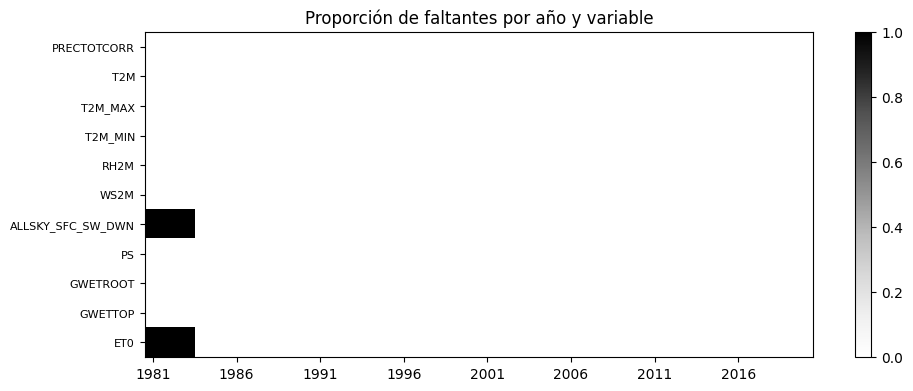

In [5]:
falt = train_df[VARS].isna()
print((falt.mean() * 100).round(2).sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
m = falt.groupby(train_df["fecha"].dt.year).mean()
im = ax.imshow(m.T, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_yticks(range(len(VARS))); ax.set_yticklabels(VARS, fontsize=8)
ax.set_xticks(range(0, len(m), 5)); ax.set_xticklabels(m.index[::5])
ax.set_title("Proporción de faltantes por año y variable"); fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

**Mecanismo.** La prueba de Little no está disponible en las librerías del proyecto, así que el mecanismo se evalúa comparando las distribuciones de las demás variables entre filas con y sin faltante. Si los faltantes se concentran en ciertos años (por ejemplo, la radiación al inicio del registro), el mecanismo es MAR respecto a la fecha y no MCAR.

In [6]:
from scipy import stats
filas = []
for v in VARS:
    faltante = train_df[v].isna()
    if faltante.sum() < 30:
        continue
    for w in VARS:
        if w == v:
            continue
        a, b = train_df.loc[faltante, w].dropna(), train_df.loc[~faltante, w].dropna()
        if len(a) > 30:
            ks = stats.ks_2samp(a, b)
            filas.append((v, w, ks.statistic, ks.pvalue))
    anios = train_df.loc[faltante, "fecha"].dt.year
    print(f"{v}: {faltante.sum()} faltantes, años {anios.min()}–{anios.max()}")
pd.DataFrame(filas, columns=["con faltante", "comparada", "KS D", "p"]).sort_values("KS D", ascending=False).head(15)

ALLSKY_SFC_SW_DWN: 1095 faltantes, años 1981–1983
ET0: 1095 faltantes, años 1981–1983


,con faltante,comparada,KS D,p
16,ET0,GWETROOT,0.1769,3.409e-28
7,ALLSKY_SFC_SW_DWN,GWETROOT,0.1769,3.409e-28
17,ET0,GWETTOP,0.1724,8.312e-27
8,ALLSKY_SFC_SW_DWN,GWETTOP,0.1724,8.312e-27
6,ALLSKY_SFC_SW_DWN,PS,0.1105,3.179e-11
15,ET0,PS,0.1105,3.179e-11
13,ET0,RH2M,0.07943,5.252e-06
4,ALLSKY_SFC_SW_DWN,RH2M,0.07943,5.252e-06
9,ET0,PRECTOTCORR,0.0634,0.0005543
0,ALLSKY_SFC_SW_DWN,PRECTOTCORR,0.0634,0.0005543


**Interpretación.** Solo la radiación solar, y por tanto la ET0, tiene faltantes: el 6,7 % de los días, concentrados completamente en 1981–1983. El faltante depende del periodo y no es aleatorio (no es MCAR): las demás variables difieren significativamente entre los años con y sin radiación, porque 1982–1983 fueron años secos de El Niño. Es un mecanismo MAR respecto a la fecha. Como la radiación entra al modelo solo como medias móviles, se imputa dentro del Pipeline con la mediana de entrenamiento y se reconoce que el modelo es menos confiable para esos años. No hay fechas faltantes, duplicados ni temperaturas incoherentes. El tamaño (16.436 días) está por debajo de las 20.000 observaciones sugeridas; el diseño regional del notebook 00 resuelve esta limitación.

## 1.5 Duplicados y casi-duplicados

In [7]:
print("Filas duplicadas exactas:", train_df.duplicated().sum())
print("Claves (punto, fecha) repetidas:", train_df.duplicated(["punto", "fecha"]).sum())
completo = pd.date_range(train_df.fecha.min(), train_df.fecha.max(), freq="D")
for p_, g in train_df.groupby("punto"):
    print(f"{p_}: días faltantes en el calendario = {len(completo.difference(g.fecha))}")
# Casi-duplicados: días consecutivos con todas las variables idénticas (relleno por error)
iguales = train_df.sort_values(["punto", "fecha"]).groupby("punto")[VARS].diff().abs().sum(axis=1) == 0
print("Días idénticos al anterior en todas las variables:", int(iguales.sum()))

Filas duplicadas exactas: 0
Claves (punto, fecha) repetidas: 0
FINCA_SABANAGRANDE: días faltantes en el calendario = 0
Días idénticos al anterior en todas las variables: 1


## 1.6 Valores imposibles o inconsistentes

In [8]:
reglas = {
    "PRECTOTCORR": (0, 500), "T2M": (5, 45), "T2M_MAX": (5, 50), "T2M_MIN": (0, 40),
    "RH2M": (0, 100), "WS2M": (0, 40), "ALLSKY_SFC_SW_DWN": (0, 35),
    "PS": (80, 110), "GWETROOT": (0, 1), "GWETTOP": (0, 1), "ET0": (0, 15),
}
tabla = []
for v, (lo, hi) in reglas.items():
    if v in train_df:
        s = train_df[v]
        tabla.append((v, lo, hi, int((s < lo).sum()), int((s > hi).sum())))
display(pd.DataFrame(tabla, columns=["variable", "mín plausible", "máx plausible", "< mín", "> máx"]))
print("T2M_MIN > T2M_MAX:", int((train_df.T2M_MIN > train_df.T2M_MAX).sum()))
print("Coordenadas fuera de rango:", int((~train_df.lat.between(-90, 90) | ~train_df.lon.between(-180, 180)).sum()))

,variable,mín plausible,máx plausible,< mín,> máx
0,PRECTOTCORR,0,500,0,0
1,T2M,5,45,0,0
2,T2M_MAX,5,50,0,0
3,T2M_MIN,0,40,0,0
4,RH2M,0,100,0,0
5,WS2M,0,40,0,0
6,ALLSKY_SFC_SW_DWN,0,35,0,0
7,PS,80,110,0,0
8,GWETROOT,0,1,0,0
9,GWETTOP,0,1,0,0


T2M_MIN > T2M_MAX: 0
Coordenadas fuera de rango: 0


## 1.7 Sesgos de muestreo y representatividad

POWER entrega valores promedio de una celda de grilla (del orden de 50 km), no mediciones en la finca. Eso implica que:

- la lluvia convectiva local (aguaceros muy concentrados) se suaviza, por lo que los extremos diarios reales pueden ser mayores que los del dataset;
- la precipitación está corregida con datos satelitales y de estaciones, y su calidad es menor en zonas con pocas estaciones;
- la grilla cubre el Caribe continental bajo (≤ 400 m); las zonas de montaña se excluyeron a propósito.

**Recomendación:** contrastar la serie con estaciones del IDEAM cercanas (o con registros de la finca, si existen) para cuantificar el sesgo, en particular el aumento de lluvia de 2022–2025.

## 1.8 Consideraciones éticas

El dataset no contiene datos personales. La ubicación de la finca se representa con coordenadas aproximadas del municipio, que no permiten identificarla. Las fuentes son de acceso abierto (NASA POWER y NOAA-CPC, uso libre con citación).